Single-cell time-resolved structure (simulation only, first)
These establish that the model behaves sensibly at the single-cell level.
1. **Total protein mass vs time**
2. **Total RNA (mRNA + rRNA) vs time**
3. **Protein mass vs RNA nt**

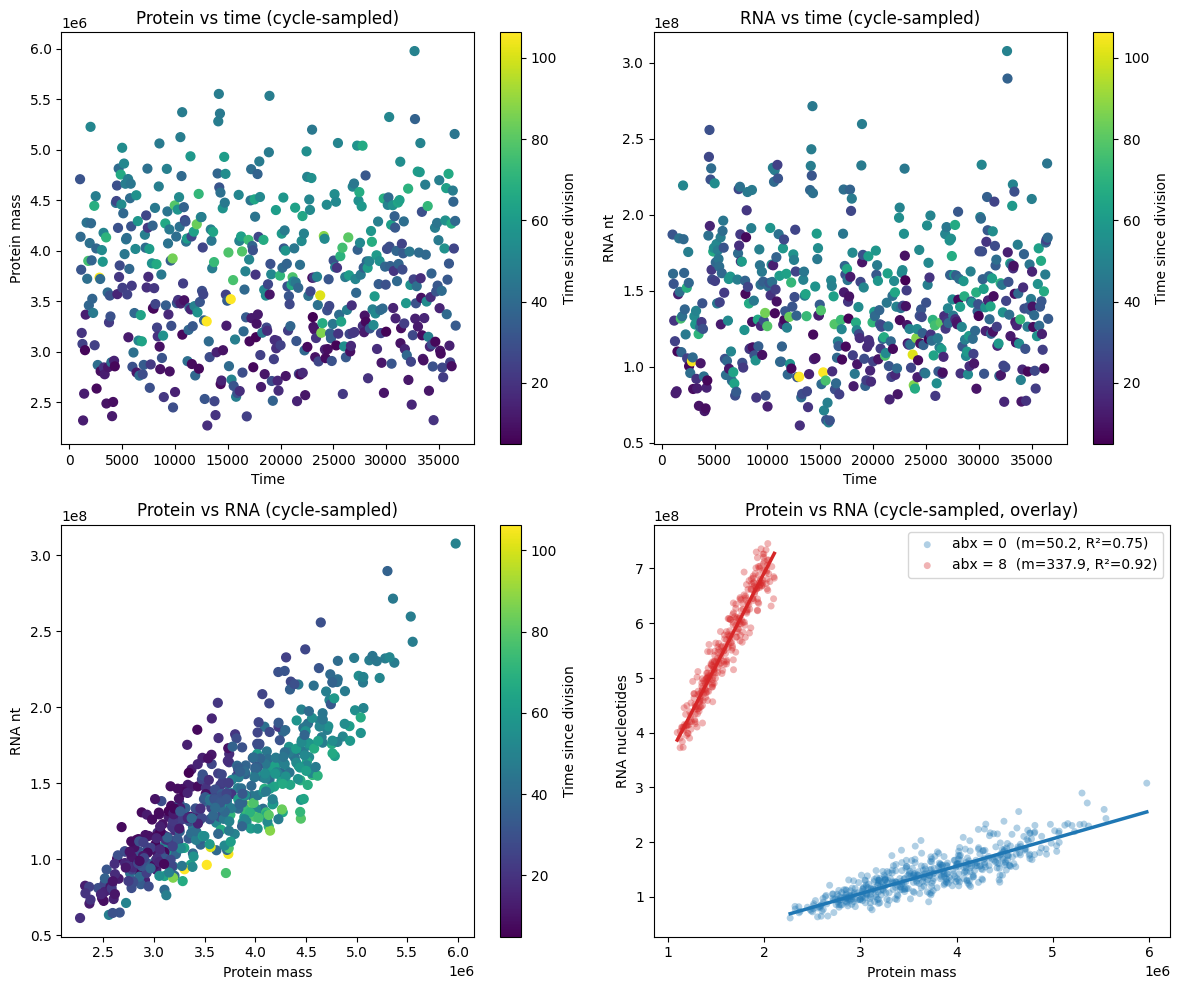

abx=0 slope: 50.150063779502915 R^2: 0.7537903195075936
abx=8 slope: 337.9408288098793 R^2: 0.9247427559028095


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pyarrow as pa
import pyarrow.ipc as ipc

# ============================================================
# PARAMETERS
# ============================================================
NS = 0.74
ABX_BASE = 0
ABX_PERT = 8

FILES = {
    (NS, ABX_BASE): "Data/ns074.arrow",
    (NS, ABX_PERT): "Data/ns074/abx8.arrow",
}

NR = 7549.0
NX = 300.0
RIBO_RNA_NT = 4565
BURN_IN = 1000.0

# ============================================================
# HELPERS
# ============================================================

def load_arrow(path):
    with pa.memory_map(path, "r") as src:
        return ipc.open_file(src).read_all().to_pandas()

def compute_protein(df):
    return (
        df["r(t)"] + df["q(t)"] + df["et(t)"] + df["em(t)"]
    ).to_numpy()

def compute_mass(df):
    r   = df["r(t)"].to_numpy()
    rmm = df["rmm(t)"].to_numpy()
    rmt = df["rmt(t)"].to_numpy()
    rmq = df["rmq(t)"].to_numpy()
    rmr = df["rmr(t)"].to_numpy()
    zmm = df["zmm(t)"].to_numpy()
    zmt = df["zmt(t)"].to_numpy()
    zmq = df["zmq(t)"].to_numpy()
    zmr = df["zmr(t)"].to_numpy()
    q   = df["q(t)"].to_numpy()
    et  = df["et(t)"].to_numpy()
    em  = df["em(t)"].to_numpy()

    ribo_mass = NR * (r + rmm + rmt + rmq + rmr + zmm + zmt + zmq + zmr)
    non_ribo  = NX * (q + et + em)

    return ribo_mass + non_ribo

def compute_RNA_nt(df):
    mm = (df["mm(t)"] + df["rmm(t)"] + df["zmm(t)"]) * (3 * NX)
    mt = (df["mt(t)"] + df["rmt(t)"] + df["zmt(t)"]) * (3 * NX)
    mq = (df["mq(t)"] + df["rmq(t)"] + df["zmq(t)"]) * (3 * NX)
    mr = (df["mr(t)"] + df["rmr(t)"] + df["zmr(t)"]) * (3 * NR)

    r_tot = (
        df["r(t)"] + df["rmm(t)"] + df["rmt(t)"] +
        df["rmq(t)"] + df["rmr(t)"] +
        df["zmm(t)"] + df["zmt(t)"] +
        df["zmq(t)"] + df["zmr(t)"]
    )

    return (mm + mt + mq + mr + r_tot * RIBO_RNA_NT).to_numpy()

# ------------------------------------------------------------
# Detect division peaks from total mass
# ------------------------------------------------------------
def detect_divisions_from_mass(total_mass):
    dx = np.diff(total_mass)
    slope = np.sign(dx)
    dslope = np.diff(slope)
    max_indices = np.where(dslope == -2)[0] + 1
    return max_indices

# ------------------------------------------------------------
# Compute time since division (correctly)
# ------------------------------------------------------------
def compute_time_since_division(t, total_mass):
    div_idx = detect_divisions_from_mass(total_mass)

    tau = np.zeros_like(t)
    last_div_time = t[0]

    div_set = set(div_idx)

    for i in range(len(t)):
        if i in div_set:
            last_div_time = t[i]
        tau[i] = t[i] - last_div_time

    return tau

# ------------------------------------------------------------
# Random sample one point per cell cycle
# ------------------------------------------------------------
def sample_random_per_cycle(total_mass, guard_frac=0.1, seed=0):
    rng = np.random.default_rng(seed)

    div_idx = detect_divisions_from_mass(total_mass)
    div_idx = np.concatenate(([0], div_idx, [len(total_mass)-1]))

    sample_indices = []

    for i in range(len(div_idx)-1):
        start = div_idx[i]
        end   = div_idx[i+1]

        L = end - start
        if L < 10:
            continue

        g = int(guard_frac * L)
        lo = start + g
        hi = end - g

        if hi <= lo:
            continue

        sample_indices.append(rng.integers(lo, hi))

    return np.array(sample_indices)

# ============================================================
# LOAD DATA (random per-cycle sampling)
# ============================================================
data = {}

for key, fn in FILES.items():
    df = load_arrow(fn)
    df = df[df["timestamp"] >= BURN_IN]

    t = df["timestamp"].to_numpy()
    mass = compute_mass(df)
    prot = compute_protein(df) #/mass
    rna = compute_RNA_nt(df) #/mass

    tau = compute_time_since_division(t, mass)

    # Random one point per cell cycle
    idx = sample_random_per_cycle(mass)

    data[key] = dict(
        t=t[idx],
        protein=prot[idx],
        rna=rna[idx],
        tau=tau[idx]
    )

# ============================================================
# PLOTS: A1–A4 (pseudo-population)
# ============================================================
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
cmap = "viridis"

# A1
ax = axes[0, 0]
sc = ax.scatter(
    data[(NS, ABX_BASE)]["t"],
    data[(NS, ABX_BASE)]["protein"],
    c=data[(NS, ABX_BASE)]["tau"],
    s=40,
    cmap=cmap
)
ax.set_title("Protein vs time (cycle-sampled)")
ax.set_xlabel("Time")
ax.set_ylabel("Protein mass")
plt.colorbar(sc, ax=ax, label="Time since division")

# A2
ax = axes[0, 1]
sc = ax.scatter(
    data[(NS, ABX_BASE)]["t"],
    data[(NS, ABX_BASE)]["rna"],
    c=data[(NS, ABX_BASE)]["tau"],
    s=40,
    cmap=cmap
)
ax.set_title("RNA vs time (cycle-sampled)")
ax.set_xlabel("Time")
ax.set_ylabel("RNA nt")
plt.colorbar(sc, ax=ax, label="Time since division")

# A3
ax = axes[1, 0]
sc = ax.scatter(
    data[(NS, ABX_BASE)]["protein"],
    data[(NS, ABX_BASE)]["rna"],
    c=data[(NS, ABX_BASE)]["tau"],
    s=40,
    cmap=cmap
)
ax.set_title("Protein vs RNA (cycle-sampled)")
ax.set_xlabel("Protein mass")
ax.set_ylabel("RNA nt")
plt.colorbar(sc, ax=ax, label="Time since division")

# A4
ax = axes[1, 1]

# Extract data
prot_base = data[(NS, ABX_BASE)]["protein"]
rna_base  = data[(NS, ABX_BASE)]["rna"]

prot_pert = data[(NS, ABX_PERT)]["protein"]
rna_pert  = data[(NS, ABX_PERT)]["rna"]
# Fit lines
coef_base = np.polyfit(prot_base, rna_base, 1)
coef_pert = np.polyfit(prot_pert, rna_pert, 1)

# Compute R^2
r2_base = np.corrcoef(prot_base, rna_base)[0, 1]**2
r2_pert = np.corrcoef(prot_pert, rna_pert)[0, 1]**2


# Scatter (lighter, cleaner, no edge)
ax.scatter(
    prot_base,
    rna_base,
    color="#1f77b4",
    s=25,
    alpha=0.35,
    edgecolors="none",
    label=f"abx = 0  (m={coef_base[0]:.1f}, R²={r2_base:.2f})"
)

ax.scatter(
    prot_pert,
    rna_pert,
    color="#d62728",
    s=25,
    alpha=0.35,
    edgecolors="none",
    label=f"abx = 8  (m={coef_pert[0]:.1f}, R²={r2_pert:.2f})"
)


# Fit lines

x_base = np.linspace(prot_base.min(), prot_base.max(), 200)
x_pert = np.linspace(prot_pert.min(), prot_pert.max(), 200)

y_base = np.polyval(coef_base, x_base)
y_pert = np.polyval(coef_pert, x_pert)


# Regression lines (match color, slightly thicker)
ax.plot(
    x_base, y_base,
    color="#1f77b4",
    linewidth=2.5
)

ax.plot(
    x_pert, y_pert,
    color="#d62728",
    linewidth=2.5
)


# -------------------------------------------------

ax.set_title("Protein vs RNA (cycle-sampled, overlay)")
ax.set_xlabel("Protein mass")
ax.set_ylabel("RNA nucleotide")
ax.legend()

plt.tight_layout()
plt.show()

# Compute R^2
r_base = np.corrcoef(prot_base, rna_base)[0, 1]**2
r_pert = np.corrcoef(prot_pert, rna_pert)[0, 1]**2

print("abx=0 slope:", coef_base[0], "R^2:", r_base)
print("abx=8 slope:", coef_pert[0], "R^2:", r_pert)


Next is with outliers removed using IQR outlier cutoff.

Extreme late-cycle events were identified using a 1.5×IQR criterion applied to time-since-division (τ). Approximately 0.8% of points were excluded.

To assess whether extreme late–cell-cycle events influenced the observed RNA–protein relationships, we identified outliers in time since division (τ) using a standard interquartile range (IQR) criterion (1.5×IQR). No outliers were detected in protein or RNA abundance individually, indicating that the molecular distributions were well-behaved. However, four observations (~0.8% of 491 sampled cycles) were identified as extreme right-tail events in τ (τ ≈ 101–106), corresponding to unusually long cell-cycle durations. These points were removed and the RNA–protein regression was recomputed to test robustness. Excluding these extreme τ events had a negligible effect on the scaling relationship (slope changed from 50.15 to 50.07; R² from 0.754 to 0.757), demonstrating that the RNA–protein coupling is robust and not driven by rare late-cycle states. 

Total points: 491
Protein outliers: 0
RNA outliers: 0
Removed (either variable): 0
Percent removed: 0.0 %
tau min: 4.900011543901201
tau max: 106.30387262307522
tau mean: 37.26464959159221
Tau outliers: 4
Percent removed: 0.814663951120163 %
Points after tau filtering: 487
abx=8 tau removed: 0


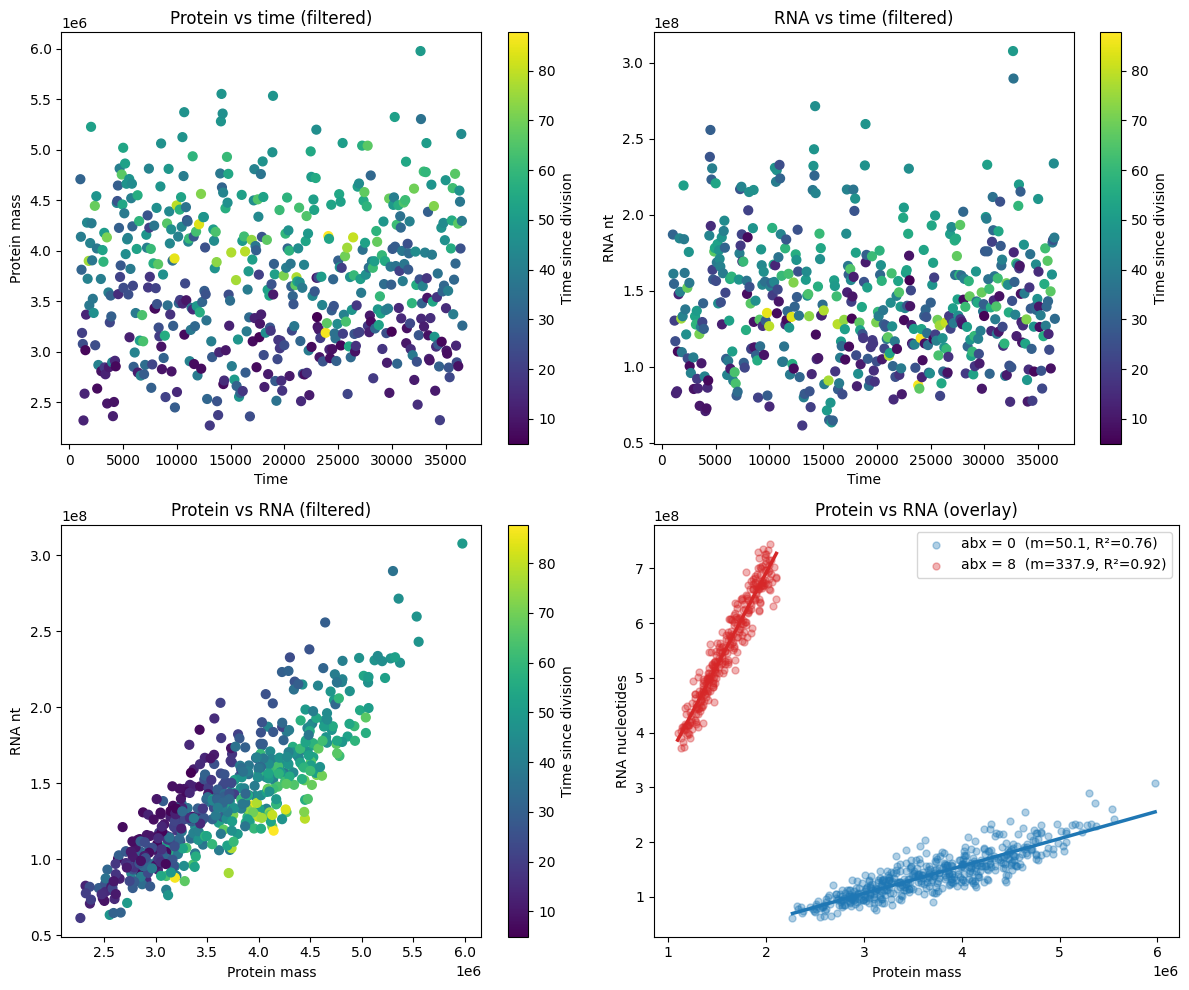

abx=0 slope: 50.06723306592541 R^2: 0.7570185021474902
abx=8 slope: 337.9408288098793 R^2: 0.9247427559028095
Max tau before: 106.30387262307522
Max tau after: 87.71130882778743
Tau values removed:
[104.97135283 106.0513037  106.30387262 101.158477  ]
Filtered slope: 50.06723306592541
Filtered R^2: 0.7570185021474902
Original abx=8 points: 293
abx=0 points used in A4: 487
abx=8 points used in A4: 293


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pyarrow as pa
import pyarrow.ipc as ipc

# ============================================================
# PARAMETERS
# ============================================================
NS = 0.74
ABX_BASE = 0
ABX_PERT = 12

FILES = {
    (NS, ABX_BASE): "Data/ns074.arrow",
    (NS, ABX_PERT): "Data/ns074/abx12.arrow",
}

NR = 7549.0
NX = 300.0
RIBO_RNA_NT = 4565
BURN_IN = 1000.0

# ============================================================
# HELPERS
# ============================================================

def load_arrow(path):
    with pa.memory_map(path, "r") as src:
        return ipc.open_file(src).read_all().to_pandas()

def compute_protein(df):
    return (
        df["r(t)"] + df["q(t)"] + df["et(t)"] + df["em(t)"]
    ).to_numpy()

def compute_mass(df):
    r   = df["r(t)"].to_numpy()
    rmm = df["rmm(t)"].to_numpy()
    rmt = df["rmt(t)"].to_numpy()
    rmq = df["rmq(t)"].to_numpy()
    rmr = df["rmr(t)"].to_numpy()
    zmm = df["zmm(t)"].to_numpy()
    zmt = df["zmt(t)"].to_numpy()
    zmq = df["zmq(t)"].to_numpy()
    zmr = df["zmr(t)"].to_numpy()
    q   = df["q(t)"].to_numpy()
    et  = df["et(t)"].to_numpy()
    em  = df["em(t)"].to_numpy()

    ribo_mass = NR * (r + rmm + rmt + rmq + rmr + zmm + zmt + zmq + zmr)
    non_ribo  = NX * (q + et + em)

    return ribo_mass + non_ribo

def compute_RNA_nt(df):
    mm = (df["mm(t)"] + df["rmm(t)"] + df["zmm(t)"]) * (3 * NX)
    mt = (df["mt(t)"] + df["rmt(t)"] + df["zmt(t)"]) * (3 * NX)
    mq = (df["mq(t)"] + df["rmq(t)"] + df["zmq(t)"]) * (3 * NX)
    mr = (df["mr(t)"] + df["rmr(t)"] + df["zmr(t)"]) * (3 * NR)

    r_tot = (
        df["r(t)"] + df["rmm(t)"] + df["rmt(t)"] +
        df["rmq(t)"] + df["rmr(t)"] +
        df["zmm(t)"] + df["zmt(t)"] +
        df["zmq(t)"] + df["zmr(t)"]
    )

    return (mm + mt + mq + mr + r_tot * RIBO_RNA_NT).to_numpy()

# ------------------------------------------------------------
# IQR OUTLIER MASK (STANDARD METHOD)
# ------------------------------------------------------------
def iqr_mask(x, k=3.0):
    q1 = np.percentile(x, 25)
    q3 = np.percentile(x, 75)
    iqr = q3 - q1
    lower = q1 - k * iqr
    upper = q3 + k * iqr
    return (x >= lower) & (x <= upper)

# ------------------------------------------------------------
# Division helpers (unchanged)
# ------------------------------------------------------------
def detect_divisions_from_mass(total_mass):
    dx = np.diff(total_mass)
    slope = np.sign(dx)
    dslope = np.diff(slope)
    max_indices = np.where(dslope == -2)[0] + 1
    return max_indices

def compute_time_since_division(t, total_mass):
    div_idx = detect_divisions_from_mass(total_mass)
    tau = np.zeros_like(t)
    last_div_time = t[0]
    div_set = set(div_idx)

    for i in range(len(t)):
        if i in div_set:
            last_div_time = t[i]
        tau[i] = t[i] - last_div_time

    return tau

def sample_random_per_cycle(total_mass, guard_frac=0.1, seed=0):
    rng = np.random.default_rng(seed)
    div_idx = detect_divisions_from_mass(total_mass)
    div_idx = np.concatenate(([0], div_idx, [len(total_mass)-1]))

    sample_indices = []

    for i in range(len(div_idx)-1):
        start = div_idx[i]
        end   = div_idx[i+1]
        L = end - start
        if L < 10:
            continue
        g = int(guard_frac * L)
        lo = start + g
        hi = end - g
        if hi <= lo:
            continue
        sample_indices.append(rng.integers(lo, hi))

    return np.array(sample_indices)

# ============================================================
# LOAD DATA
# ============================================================
data = {}

for key, fn in FILES.items():
    df = load_arrow(fn)
    df = df[df["timestamp"] >= BURN_IN]

    t = df["timestamp"].to_numpy()
    mass = compute_mass(df)
    prot = compute_protein(df)
    rna = compute_RNA_nt(df)
    tau = compute_time_since_division(t, mass)

    idx = sample_random_per_cycle(mass)

    data[key] = dict(
        t=t[idx],
        protein=prot[idx],
        rna=rna[idx],
        tau=tau[idx]
    )

# ============================================================
# APPLY OUTLIER FILTER (abx = 0 only for A1–A3)
# ============================================================
base = data[(NS, ABX_BASE)]

prot_vals = base["protein"]
rna_vals  = base["rna"]

mask_prot = iqr_mask(prot_vals, k=3.0)
mask_rna  = iqr_mask(rna_vals,  k=3.0)
mask_both = mask_prot & mask_rna

N_total = len(prot_vals)
N_prot_out = np.sum(~mask_prot)
N_rna_out  = np.sum(~mask_rna)
N_either   = np.sum(~mask_both)

print("Total points:", N_total)
print("Protein outliers:", N_prot_out)
print("RNA outliers:", N_rna_out)
print("Removed (either variable):", N_either)
print("Percent removed:", 100 * N_either / N_total, "%")
tau_vals = base["tau"]

print("tau min:", np.min(tau_vals))
print("tau max:", np.max(tau_vals))
print("tau mean:", np.mean(tau_vals))
mask_tau = iqr_mask(tau_vals, k=1.5)

N_tau_out = np.sum(~mask_tau)
print("Tau outliers:", N_tau_out)
print("Percent removed:", 100 * N_tau_out / len(tau_vals), "%")

# ------------------------------------------------------------
# APPLY TAU FILTER TO A1–A3
# ------------------------------------------------------------

mask_clean = mask_tau   # only remove tau outliers

t_f    = base["t"][mask_clean]
prot_f = base["protein"][mask_clean]
rna_f  = base["rna"][mask_clean]
tau_f  = base["tau"][mask_clean]

print("Points after tau filtering:", len(t_f))


# ============================================================
# PLOTS
# ============================================================
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
cmap = "viridis"

# A1
ax = axes[0, 0]
sc = ax.scatter(t_f, prot_f, c=tau_f, s=40, cmap=cmap)
ax.set_title("Protein vs time (filtered)")
ax.set_xlabel("Time")
ax.set_ylabel("Protein mass")
plt.colorbar(sc, ax=ax, label="Time since division")

# A2
ax = axes[0, 1]
sc = ax.scatter(t_f, rna_f, c=tau_f, s=40, cmap=cmap)
ax.set_title("RNA vs time (filtered)")
ax.set_xlabel("Time")
ax.set_ylabel("RNA nt")
plt.colorbar(sc, ax=ax, label="Time since division")

# A3
ax = axes[1, 0]
sc = ax.scatter(prot_f, rna_f, c=tau_f, s=40, cmap=cmap)
ax.set_title("Protein vs RNA (filtered)")
ax.set_xlabel("Protein mass")
ax.set_ylabel("RNA nt")
plt.colorbar(sc, ax=ax, label="Time since division")

# A4 unchanged
ax = axes[1, 1]

# --- Use filtered data for abx = 0 ---
prot_base = prot_f
rna_base  = rna_f

# --- Apply tau filtering to abx = 8 as well ---
pert = data[(NS, ABX_PERT)]

tau_pert_vals = pert["tau"]
mask_tau_pert = iqr_mask(tau_pert_vals, k=1.5)

prot_pert = pert["protein"][mask_tau_pert]
rna_pert  = pert["rna"][mask_tau_pert]

print("abx=8 tau removed:", np.sum(~mask_tau_pert))


coef_base = np.polyfit(prot_base, rna_base, 1)
coef_pert = np.polyfit(prot_pert, rna_pert, 1)

r2_base = np.corrcoef(prot_base, rna_base)[0, 1]**2
r2_pert = np.corrcoef(prot_pert, rna_pert)[0, 1]**2

ax.scatter(prot_base, rna_base,
           color="#1f77b4", s=25, alpha=0.35,
           label=f"abx = 0  (m={coef_base[0]:.1f}, R²={r2_base:.2f})")

ax.scatter(prot_pert, rna_pert,
           color="#d62728", s=25, alpha=0.35,
           label=f"abx = 8  (m={coef_pert[0]:.1f}, R²={r2_pert:.2f})")

x_base = np.linspace(prot_base.min(), prot_base.max(), 200)
x_pert = np.linspace(prot_pert.min(), prot_pert.max(), 200)

ax.plot(x_base, np.polyval(coef_base, x_base), color="#1f77b4", linewidth=2.5)
ax.plot(x_pert, np.polyval(coef_pert, x_pert), color="#d62728", linewidth=2.5)

ax.set_title("Protein vs RNA (overlay)")
ax.set_xlabel("Protein mass")
ax.set_ylabel("RNA nucleotides")
ax.legend()

plt.tight_layout()
plt.show()

print("abx=0 slope:", coef_base[0], "R^2:", r2_base)
print("abx=8 slope:", coef_pert[0], "R^2:", r2_pert)
print("Max tau before:", np.max(base["tau"]))
print("Max tau after:", np.max(tau_f))
print("Tau values removed:")
print(tau_vals[~mask_tau])
coef_base_filtered = np.polyfit(prot_f, rna_f, 1)
r2_base_filtered = np.corrcoef(prot_f, rna_f)[0,1]**2

print("Filtered slope:", coef_base_filtered[0])
print("Filtered R^2:", r2_base_filtered)
print("Original abx=8 points:", len(data[(NS, ABX_PERT)]["protein"]))
print("abx=0 points used in A4:", len(prot_base))
print("abx=8 points used in A4:", len(prot_pert))




      ns  abx  corr_ratio_rna  corr_ratio_protein
0   0.45    0        0.998695           -0.998635
1   0.45    2        0.999019           -0.996707
2   0.45    4        0.997556           -0.991748
3   0.45    8        0.993600           -0.985480
4   0.45   12        0.998826           -0.997214
5   0.74    0        0.999322           -0.998681
6   0.74    2        0.998920           -0.996599
7   0.74    4        0.997842           -0.994967
8   0.74    8        0.995183           -0.991419
9   0.74   12        0.996154           -0.986483
10  1.03    0        0.999127           -0.998312
11  1.03    2        0.998955           -0.996959
12  1.03    4        0.997850           -0.995150
13  1.03    8        0.994867           -0.991235
14  1.03   12        0.990396           -0.959935
15  1.76    0        0.998590           -0.997356
16  1.76    2        0.998519           -0.996508
17  1.76    4        0.997727           -0.995954
18  1.76    8        0.988150           -0.984632


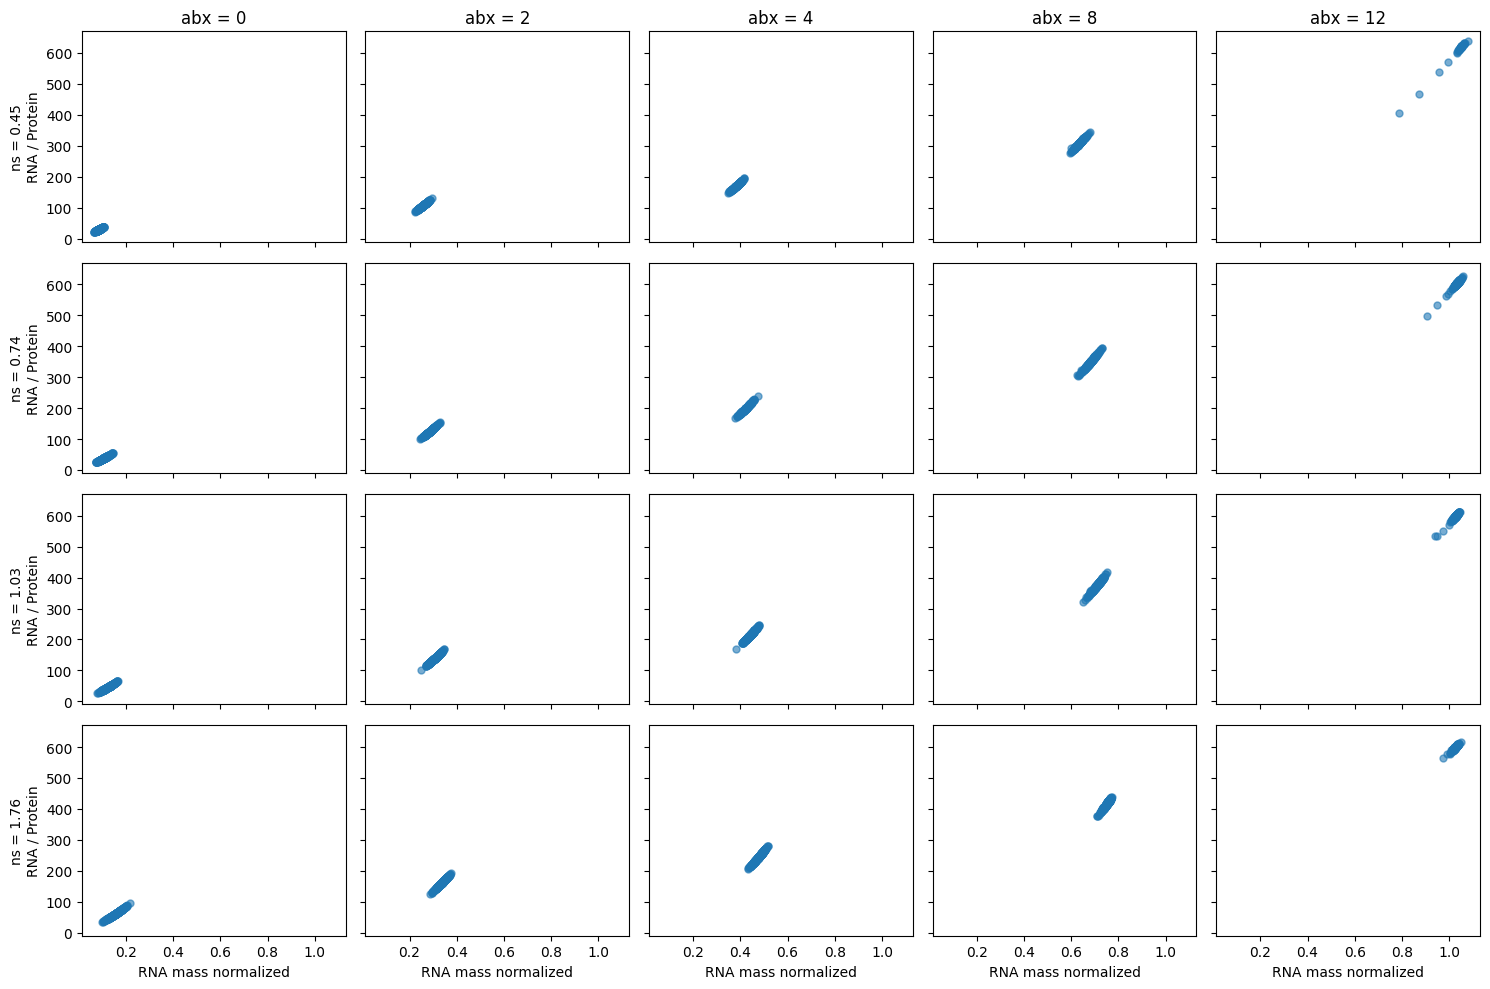

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pyarrow as pa
import pyarrow.ipc as ipc

# ============================================================
# PARAMETERS
# ============================================================
NS_VALUES  = [0.45, 0.74, 1.03, 1.76]
ABX_VALUES = [0, 2, 4, 8, 12]

NR = 7549.0
NX = 300.0
RIBO_RNA_NT = 4565
BURN_IN = 1000.0
SAMPLING_MODE = "random"  # "pre", "post", "random"

# ============================================================
# HELPERS
# ============================================================
def load_arrow(path):
    with pa.memory_map(path, "r") as src:
        return ipc.open_file(src).read_all().to_pandas()

def compute_protein(df):
    return (
        df["r(t)"] + df["q(t)"] + df["et(t)"] + df["em(t)"]
    ).to_numpy()

def compute_mass(df):
    r   = df["r(t)"].to_numpy()
    rmm = df["rmm(t)"].to_numpy()
    rmt = df["rmt(t)"].to_numpy()
    rmq = df["rmq(t)"].to_numpy()
    rmr = df["rmr(t)"].to_numpy()
    zmm = df["zmm(t)"].to_numpy()
    zmt = df["zmt(t)"].to_numpy()
    zmq = df["zmq(t)"].to_numpy()
    zmr = df["zmr(t)"].to_numpy()
    q   = df["q(t)"].to_numpy()
    et  = df["et(t)"].to_numpy()
    em  = df["em(t)"].to_numpy()

    ribo_mass = NR * (r + rmm + rmt + rmq + rmr + zmm + zmt + zmq + zmr)
    non_ribo  = NX * (q + et + em)

    return ribo_mass, non_ribo

def compute_RNA_nt(df):
    mm = (df["mm(t)"] + df["rmm(t)"] + df["zmm(t)"]) * (3 * NX)
    mt = (df["mt(t)"] + df["rmt(t)"] + df["zmt(t)"]) * (3 * NX)
    mq = (df["mq(t)"] + df["rmq(t)"] + df["zmq(t)"]) * (3 * NX)
    mr = (df["mr(t)"] + df["rmr(t)"] + df["zmr(t)"]) * (3 * NR)

    r_tot = (
        df["r(t)"] + df["rmm(t)"] + df["rmt(t)"] +
        df["rmq(t)"] + df["rmr(t)"] +
        df["zmm(t)"] + df["zmt(t)"] +
        df["zmq(t)"] + df["zmr(t)"]
    )

    return (mm + mt + mq + mr + r_tot * RIBO_RNA_NT).to_numpy()

def pearson_corr(x, y):
    return np.corrcoef(x, y)[0, 1]

# ------------------------------------------------------------
# Detect division peaks from total mass
# ------------------------------------------------------------
def detect_divisions_from_mass(total_mass):
    dx = np.diff(total_mass)
    slope = np.sign(dx)
    dslope = np.diff(slope)
    max_indices = np.where(dslope == -2)[0] + 1
    return max_indices

# ------------------------------------------------------------
# Sample one point per cell cycle
# ------------------------------------------------------------
def sample_one_per_cycle(total_mass, guard_frac=0.1, rng=None):
    """
    Pick one random index per detected cell cycle.
    guard_frac trims the first/last fraction of each cycle to avoid division artefacts.
    """
    if rng is None:
        rng = np.random.default_rng(0)  # reproducible

    div_idx = detect_divisions_from_mass(total_mass)
    div_idx = np.concatenate(([0], div_idx, [len(total_mass) - 1]))

    sample_indices = []

    for i in range(len(div_idx) - 1):
        start = div_idx[i]
        end   = div_idx[i + 1]

        L = end - start
        if L < 10:
            continue

        g = int(guard_frac * L)
        lo = start + g
        hi = end - g

        if hi <= lo:
            continue

        sample_indices.append(rng.integers(lo, hi))

    return np.array(sample_indices)

def sample_pre_division(total_mass, offset=1):
    """
    Take a point just BEFORE each division peak.
    offset=1 means one index before the peak.
    """
    div_idx = detect_divisions_from_mass(total_mass)

    sample_indices = []

    for d in div_idx:
        idx = d - offset
        if idx > 0:
            sample_indices.append(idx)

    return np.array(sample_indices)

def sample_post_division(total_mass, offset=1):
    """
    Take a point just AFTER each division peak.
    offset=1 means one index after the peak.
    """
    div_idx = detect_divisions_from_mass(total_mass)

    sample_indices = []

    for d in div_idx:
        idx = d + offset
        if idx < len(total_mass):
            sample_indices.append(idx)

    return np.array(sample_indices)


# ============================================================
# SWEEP ALL CONDITIONS (cycle sampled)
# ============================================================
records = []

for ns in NS_VALUES:
    for abx in ABX_VALUES:

        path = f"Data/ns{int(ns*100):03d}/abx{abx}.arrow"

        df = load_arrow(path)
        df = df[df["timestamp"] >= BURN_IN]

        ribo_mass, non_ribo_mass = compute_mass(df)
        total_mass = ribo_mass + non_ribo_mass

        protein = compute_protein(df) / total_mass
        rna     = compute_RNA_nt(df) / total_mass
        ratio   = rna / protein

        if SAMPLING_MODE == "pre":
            idx = sample_pre_division(total_mass)
        elif SAMPLING_MODE == "post":
            idx = sample_post_division(total_mass)
        elif SAMPLING_MODE == "random":
            idx = sample_one_per_cycle(total_mass)


        # idx = sample_one_per_cycle(total_mass)
        # idx = sample_pre_division(total_mass)
        # idx = sample_post_division(total_mass)

        protein = protein[idx]
        rna     = rna[idx]
        ratio   = ratio[idx]

        records.append({
            "ns": ns,
            "abx": abx,
            "corr_ratio_rna": pearson_corr(rna, ratio),
            "corr_ratio_protein": pearson_corr(protein, ratio),
        })

df_all = pd.DataFrame(records)
print(df_all.sort_values(["ns", "abx"]))

# ============================================================
# PLOT GRID (cycle sampled)
# ============================================================
fig, axes = plt.subplots(len(NS_VALUES), len(ABX_VALUES),
                         figsize=(15, 10),
                         sharex=True, sharey=True)

for i, ns in enumerate(NS_VALUES):
    for j, abx in enumerate(ABX_VALUES):

        if abx == 0:
            path = f"Data/ns{int(ns*100):03d}.arrow"
        else:
            path = f"Data/ns{int(ns*100):03d}/abx{abx}.arrow"

        df = load_arrow(path)
        df = df[df["timestamp"] >= BURN_IN]

        ribo_mass, non_ribo_mass = compute_mass(df)
        total_mass = ribo_mass + non_ribo_mass

        protein = compute_protein(df) / total_mass
        rna     = compute_RNA_nt(df) / total_mass
        ratio   = rna / protein

        # idx = sample_one_per_cycle(total_mass)
        # idx = sample_pre_division(total_mass)
        # idx = sample_post_division(total_mass)
        if SAMPLING_MODE == "pre":
            idx = sample_pre_division(total_mass)
        elif SAMPLING_MODE == "post":
            idx = sample_post_division(total_mass)
        elif SAMPLING_MODE == "random":
            idx = sample_one_per_cycle(total_mass)

        protein = protein[idx]
        rna     = rna[idx]
        ratio   = ratio[idx]

        ax = axes[i, j]
        ax.scatter(rna, ratio, s=25, alpha=0.6)

        if i == 0:
            ax.set_title(f"abx = {abx}")

        if j == 0:
            ax.set_ylabel(f"ns = {ns}\nRNA / Protein")

        if i == len(NS_VALUES) - 1:
            ax.set_xlabel("RNA mass normalized")

plt.tight_layout()
plt.show()

      ns  abx  n_cycles  corr_ratio_vs_rRNA_abs  corr_ratio_vs_protein_abs
0   0.45    0       497                0.663744                   0.247585
1   0.45    2       438                0.406940                   0.020046
2   0.45    4       321                0.208703                  -0.125723
3   0.45    8       229                0.098324                  -0.173175
4   0.45   12        42               -0.070892                  -0.443278
5   0.74    0       496                0.760563                   0.360493
6   0.74    2       495                0.434345                   0.027351
7   0.74    4       422                0.272281                  -0.056725
8   0.74    8       293                0.199862                  -0.085966
9   0.74   12       183                0.028674                  -0.075245
10  1.03    0       496                0.768010                   0.372017
11  1.03    2       492                0.511122                   0.093342
12  1.03    4       479  

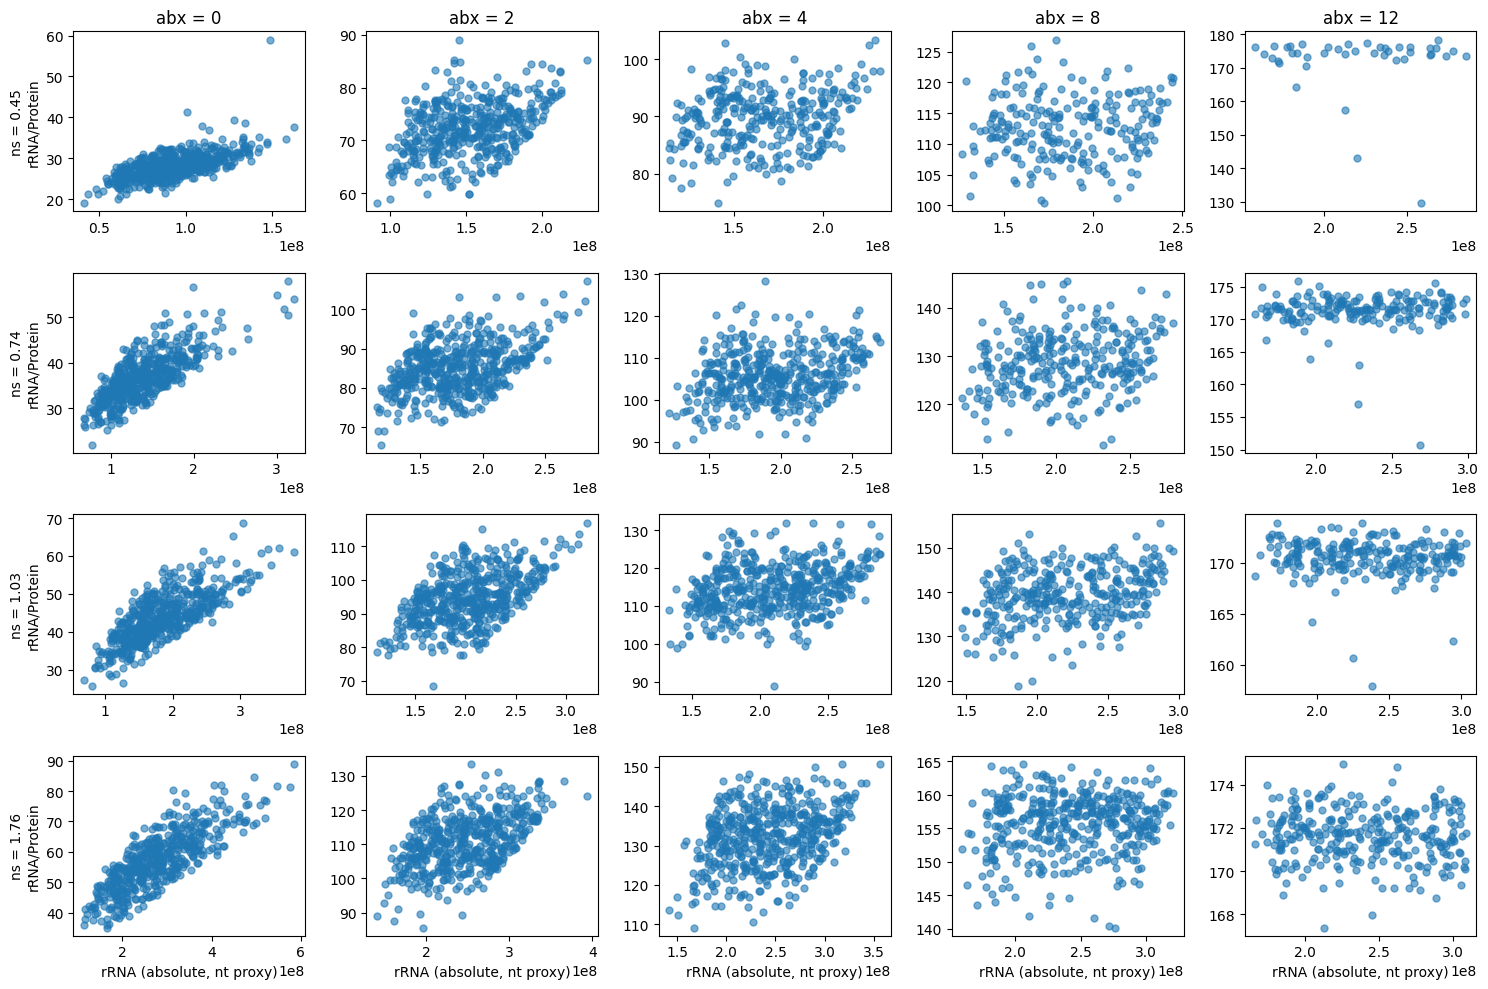

In [13]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pyarrow as pa
import pyarrow.ipc as ipc

# ============================================================
# PARAMETERS
# ============================================================
NS_VALUES  = [0.45, 0.74, 1.03, 1.76]
ABX_VALUES = [0, 2, 4, 8, 12]

RIBO_RNA_NT = 4565
BURN_IN = 1000.0

SAMPLING_MODE = "random"   # "pre", "post", "random"
GUARD_FRAC = 0.1           # for random sampling within cycle
SEED = 0

# ============================================================
# IO
# ============================================================
def load_arrow(path):
    with pa.memory_map(path, "r") as src:
        return ipc.open_file(src).read_all().to_pandas()

def build_path(ns, abx):
    ns_tag = f"{int(round(ns*100)):03d}"
    folder_style = f"Data/ns{ns_tag}/abx{abx}.arrow"
    flat_style   = f"Data/ns{ns_tag}.arrow"

    if os.path.exists(folder_style):
        return folder_style
    if abx == 0 and os.path.exists(flat_style):
        return flat_style

    raise FileNotFoundError(f"Missing file for ns={ns}, abx={abx}")

# ============================================================
# ABSOLUTE QUANTITIES
# ============================================================
def compute_protein_abs(df):
    # your “protein counts proxy”
    return (df["r(t)"] + df["q(t)"] + df["et(t)"] + df["em(t)"]).to_numpy()

def compute_total_mass(df):
    # keep using your mass to detect divisions (volume proxy)
    NR = 7549.0
    NX = 300.0

    r   = df["r(t)"].to_numpy()
    rmm = df["rmm(t)"].to_numpy()
    rmt = df["rmt(t)"].to_numpy()
    rmq = df["rmq(t)"].to_numpy()
    rmr = df["rmr(t)"].to_numpy()
    zmm = df["zmm(t)"].to_numpy()
    zmt = df["zmt(t)"].to_numpy()
    zmq = df["zmq(t)"].to_numpy()
    zmr = df["zmr(t)"].to_numpy()
    q   = df["q(t)"].to_numpy()
    et  = df["et(t)"].to_numpy()
    em  = df["em(t)"].to_numpy()

    ribo_mass = NR * (r + rmm + rmt + rmq + rmr + zmm + zmt + zmq + zmr)
    non_ribo  = NX * (q + et + em)
    return ribo_mass + non_ribo

def compute_rRNA_abs(df, include_inhibited=True):
    # ribosome pools
    r   = df["r(t)"].to_numpy()
    rmm = df["rmm(t)"].to_numpy()
    rmt = df["rmt(t)"].to_numpy()
    rmq = df["rmq(t)"].to_numpy()
    rmr = df["rmr(t)"].to_numpy()

    if include_inhibited:
        zmm = df["zmm(t)"].to_numpy()
        zmt = df["zmt(t)"].to_numpy()
        zmq = df["zmq(t)"].to_numpy()
        zmr = df["zmr(t)"].to_numpy()
        total_ribosomes = r + rmm + rmt + rmq + rmr + zmm + zmt + zmq + zmr
    else:
        total_ribosomes = r + rmm + rmt + rmq + rmr

    return total_ribosomes * RIBO_RNA_NT

# ============================================================
# DIVISION DETECTION + SAMPLING
# ============================================================
def detect_divisions(total_mass):
    dx = np.diff(total_mass)
    slope = np.sign(dx)
    dslope = np.diff(slope)
    # mass peak -> dslope == -2
    return np.where(dslope == -2)[0] + 1

def sample_random_per_cycle(total_mass, guard_frac=0.1, seed=0):
    rng = np.random.default_rng(seed)
    div_idx = detect_divisions(total_mass)
    div_idx = np.concatenate(([0], div_idx, [len(total_mass)-1]))

    indices = []
    for i in range(len(div_idx)-1):
        start = div_idx[i]
        end   = div_idx[i+1]
        L = end - start
        if L < 10:
            continue

        g = int(guard_frac * L)
        lo = start + g
        hi = end - g
        if hi <= lo:
            continue

        indices.append(rng.integers(lo, hi))

    return np.array(indices)

def sample_pre_division(total_mass, offset=1):
    div_idx = detect_divisions(total_mass)
    return np.array([d-offset for d in div_idx if d-offset > 0])

def sample_post_division(total_mass, offset=1):
    div_idx = detect_divisions(total_mass)
    return np.array([d+offset for d in div_idx if d+offset < len(total_mass)])

def choose_indices(total_mass):
    if SAMPLING_MODE == "pre":
        return sample_pre_division(total_mass)
    if SAMPLING_MODE == "post":
        return sample_post_division(total_mass)
    return sample_random_per_cycle(total_mass, guard_frac=GUARD_FRAC, seed=SEED)

# ============================================================
# CORR HELPER
# ============================================================
def corrcoef_safe(x, y):
    x = np.asarray(x)
    y = np.asarray(y)
    m = np.isfinite(x) & np.isfinite(y)
    x = x[m]; y = y[m]
    if len(x) < 3:
        return np.nan
    if np.std(x) == 0 or np.std(y) == 0:
        return np.nan
    return np.corrcoef(x, y)[0, 1]

# ============================================================
# SWEEP + TABLE
# ============================================================
records = []

for ns in NS_VALUES:
    for abx in ABX_VALUES:
        path = build_path(ns, abx)
        df = load_arrow(path)
        df = df[df["timestamp"] >= BURN_IN]

        mass = compute_total_mass(df)
        idx = choose_indices(mass)

        protein_abs = compute_protein_abs(df)[idx]
        rRNA_abs    = compute_rRNA_abs(df, include_inhibited=True)[idx]

        ratio = rRNA_abs / protein_abs

        records.append({
            "ns": ns,
            "abx": abx,
            "n_cycles": len(idx),
            "corr_ratio_vs_rRNA_abs": corrcoef_safe(rRNA_abs, ratio),
            "corr_ratio_vs_protein_abs": corrcoef_safe(protein_abs, ratio),
        })

df_all = pd.DataFrame(records).sort_values(["ns", "abx"])
print(df_all)

# ============================================================
# PLOT GRID: ratio vs rRNA_abs  (ABSOLUTE)
# ============================================================
fig, axes = plt.subplots(len(NS_VALUES), len(ABX_VALUES),
                         figsize=(15, 10),
                         sharex=False, sharey=False)

for i, ns in enumerate(NS_VALUES):
    for j, abx in enumerate(ABX_VALUES):
        path = build_path(ns, abx)
        df = load_arrow(path)
        df = df[df["timestamp"] >= BURN_IN]

        mass = compute_total_mass(df)
        idx = choose_indices(mass)

        protein_abs = compute_protein_abs(df)[idx]
        rRNA_abs    = compute_rRNA_abs(df, include_inhibited=True)[idx]
        ratio = rRNA_abs / protein_abs

        ax = axes[i, j]
        ax.scatter(rRNA_abs, ratio, s=25, alpha=0.6)

        if i == 0:
            ax.set_title(f"abx = {abx}")
        if j == 0:
            ax.set_ylabel(f"ns = {ns}\nrRNA/Protein")

        if i == len(NS_VALUES) - 1:
            ax.set_xlabel("rRNA (absolute, nt proxy)")

plt.tight_layout()
plt.show()


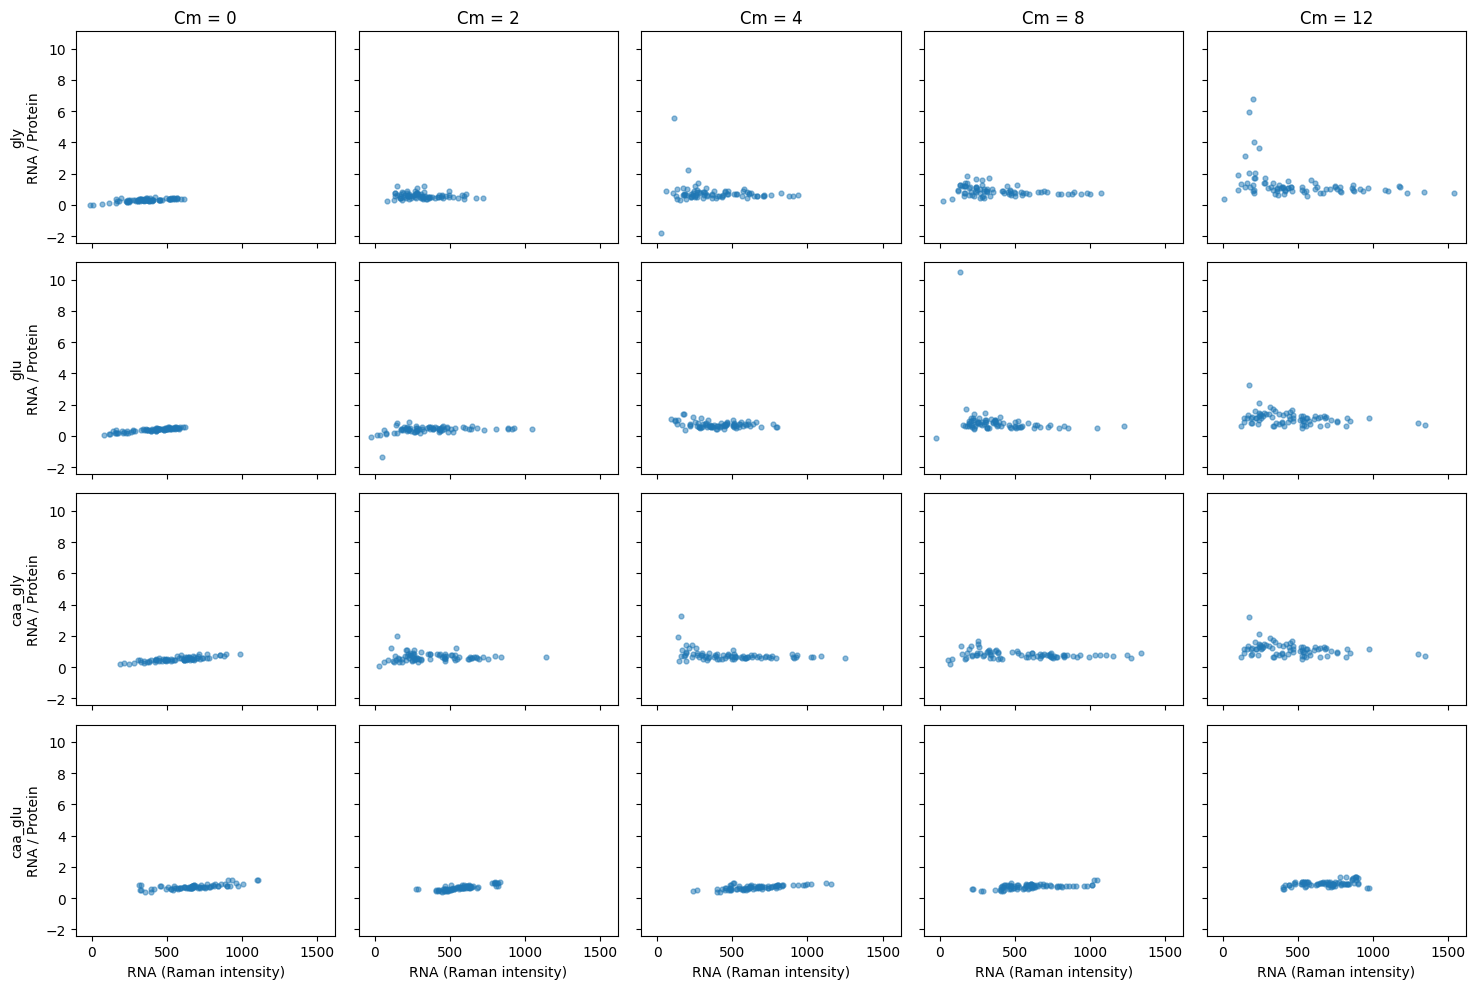

In [15]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ============================================================
# LOAD RAMAN DATA
# ============================================================
rna_df     = pd.read_csv("Data/RamanData/rna.csv")
protein_df = pd.read_csv("Data/RamanData/protein.csv")

# Slow → fast (match ns order)
nutrients = ["gly", "glu", "caa_gly", "caa_glu"]
cm_levels = [0, 2, 4, 8, 12]

# ============================================================
# GRID PLOT: RNA vs RNA/Protein ratio
# ============================================================
fig, axes = plt.subplots(
    len(nutrients),
    len(cm_levels),
    figsize=(15, 10),
    sharex=True,
    sharey=True
)

for i, nutrient in enumerate(nutrients):
    for j, cm in enumerate(cm_levels):

        col = f"Cm{cm}_{nutrient}"

        if col not in rna_df.columns or col not in protein_df.columns:
            continue

        RNA  = rna_df[col].dropna().values
        PROT = protein_df[col].dropna().values

        # Defensive alignment
        N = min(len(RNA), len(PROT))
        RNA  = RNA[:N]
        PROT = PROT[:N]

        ratio = RNA / PROT

        ax = axes[i, j]
        ax.scatter(RNA, ratio, s=12, alpha=0.5)

        # Top row → Cm labels
        if i == 0:
            ax.set_title(f"Cm = {cm}")

        # Left column → nutrient labels
        if j == 0:
            ax.set_ylabel(f"{nutrient}\nRNA / Protein")

        # Bottom row → x label
        if i == len(nutrients) - 1:
            ax.set_xlabel("RNA (Raman intensity)")

plt.tight_layout()
plt.show()


In [ ]:
# Ensure correct ordering
nutrient_order = ["gly", "glu", "caa_gly", "caa_glu"]

raman_corr["nutrient"] = pd.Categorical(
    raman_corr["nutrient"],
    categories=nutrient_order,
    ordered=True
)

raman_corr = raman_corr.sort_values(["nutrient", "abx"])

# ============================================================
# 1. Print per nutrient (across abx)
# ============================================================
print("\n=== Correlations per nutrient (across antibiotic doses) ===\n")

for nutrient in nutrient_order:
    subset = raman_corr[raman_corr["nutrient"] == nutrient]
    print(f"\nNutrient: {nutrient}")
    print(subset[["abx", "corr_ratio_rna", "corr_ratio_protein"]])


# ============================================================
# 2. Print per antibiotic dose (across nutrients)
# ============================================================
print("\n=== Correlations per antibiotic dose (across nutrients) ===\n")

for abx in sorted(raman_corr["abx"].unique()):
    subset = raman_corr[raman_corr["abx"] == abx]
    print(f"\nAntibiotic dose: {abx}")
    print(subset[["nutrient", "corr_ratio_rna", "corr_ratio_protein"]])



=== Raman correlations per nutrient (across antibiotic doses) ===

Nutrient: gly
 abx  N  pearson_r_ratio_rna  pearson_p_ratio_rna  spearman_rho_ratio_rna  spearman_p_ratio_rna  pearson_r_ratio_protein  pearson_p_ratio_protein  spearman_rho_ratio_protein  spearman_p_ratio_protein
   0 79               0.7582            5.893e-16                  0.6785             6.386e-12                 -0.03912                   0.7321                    0.007132                    0.9503
   2 79              -0.1403               0.2174                 -0.1511                0.1837                  -0.5056                2.011e-06                     -0.5897                 1.078e-08
   4 79             -0.09883               0.3862                 -0.0637                 0.577                  -0.2223                  0.04893                     -0.4361                 5.871e-05
   8 79               -0.271              0.01572                 -0.3057              0.006141                  -0.48

Correlation results (downsampled single-cell trajectory):
RNA/Protein vs total RNA:
  Pearson  r = 0.047
  Spearman ρ = 0.020

RNA/Protein vs total protein:
  Pearson  r = -0.050
  Spearman ρ = -0.047


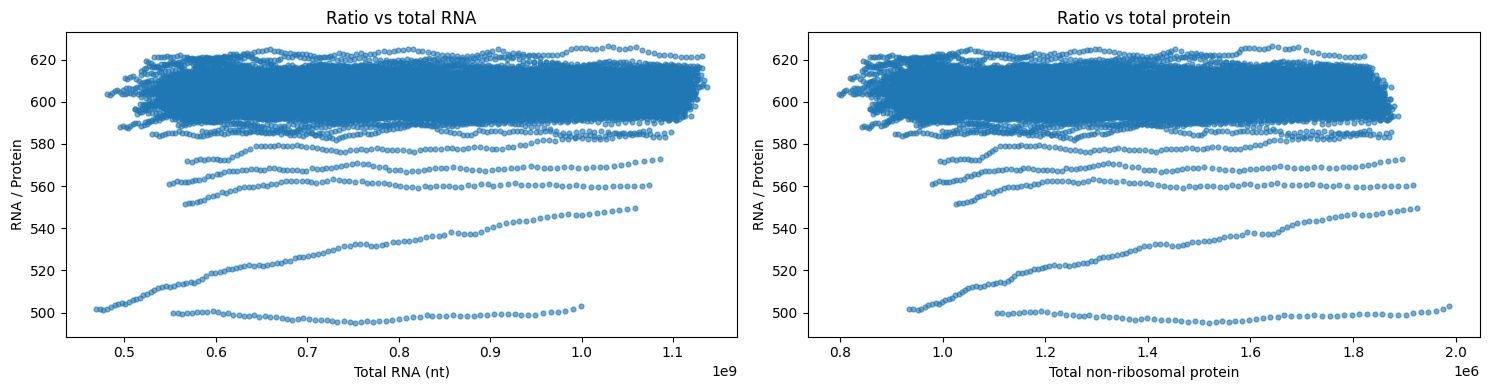

In [14]:
import numpy as np
import matplotlib.pyplot as plt
import pyarrow as pa
import pyarrow.ipc as ipc

# ============================================================
# PARAMETERS
# ============================================================
NS = 0.74
ABX = 12                       # single condition first
FILE = "Data/ns074/abx12.arrow"

NR = 7549.0
NX = 300.0
RIBO_RNA_NT = 4565
BURN_IN = 1000.0
DOWNSAMPLE = 50

# ============================================================
# HELPERS
# ============================================================
def load_arrow(path):
    with pa.memory_map(path, "r") as src:
        return ipc.open_file(src).read_all().to_pandas()

def compute_protein(df):
    # non-ribosomal protein only
    return (
        df["r(t)"] + df["q(t)"] + df["et(t)"] + df["em(t)"]
    ).to_numpy()

def compute_mass(df):
    r   = df["r(t)"].to_numpy()
    rmm = df["rmm(t)"].to_numpy()
    rmt = df["rmt(t)"].to_numpy()
    rmq = df["rmq(t)"].to_numpy()
    rmr = df["rmr(t)"].to_numpy()
    zmm = df["zmm(t)"].to_numpy()
    zmt = df["zmt(t)"].to_numpy()
    zmq = df["zmq(t)"].to_numpy()
    zmr = df["zmr(t)"].to_numpy()
    q   = df["q(t)"].to_numpy()
    et  = df["et(t)"].to_numpy()
    em  = df["em(t)"].to_numpy()

    ribo_mass = NR * (r + rmm + rmt + rmq + rmr + zmm + zmt + zmq + zmr)
    non_ribo  = NX * (q + et + em)

    return ribo_mass, non_ribo

def compute_RNA_nt(df):
    mm = (df["mm(t)"] + df["rmm(t)"] + df["zmm(t)"]) * (3 * NX)
    mt = (df["mt(t)"] + df["rmt(t)"] + df["zmt(t)"]) * (3 * NX)
    mq = (df["mq(t)"] + df["rmq(t)"] + df["zmq(t)"]) * (3 * NX)
    mr = (df["mr(t)"] + df["rmr(t)"] + df["zmr(t)"]) * (3 * NR)

    r_tot = (
        df["r(t)"] + df["rmm(t)"] + df["rmt(t)"] +
        df["rmq(t)"] + df["rmr(t)"] +
        df["zmm(t)"] + df["zmt(t)"] +
        df["zmq(t)"] + df["zmr(t)"]
    )

    return (mm + mt + mq + mr + r_tot * RIBO_RNA_NT).to_numpy()

# ============================================================
# LOAD + PROCESS DATA
# ============================================================
df = load_arrow(FILE)
df = df[df["timestamp"] >= BURN_IN]

protein = compute_protein(df)
rna     = compute_RNA_nt(df)

ribo_mass, non_ribo_mass = compute_mass(df)
total_mass = ribo_mass + non_ribo_mass

phiR = ribo_mass / total_mass
ratio = rna / protein

# ------------------------------------------------------------
# Downsample (single-cell trajectory!)
# ------------------------------------------------------------
idx = np.arange(0, len(protein), DOWNSAMPLE)

protein = protein[idx]
rna     = rna[idx]
phiR    = phiR[idx]
ratio   = ratio[idx]
# ============================================================
# CORRELATIONS
# ============================================================

def pearson_corr(x, y):
    return np.corrcoef(x, y)[0, 1]

def spearman_corr(x, y):
    rx = np.argsort(np.argsort(x))
    ry = np.argsort(np.argsort(y))
    return np.corrcoef(rx, ry)[0, 1]

corr_ratio_rna_p = pearson_corr(rna, ratio)
corr_ratio_rna_s = spearman_corr(rna, ratio)

corr_ratio_prot_p = pearson_corr(protein, ratio)
corr_ratio_prot_s = spearman_corr(protein, ratio)

print("Correlation results (downsampled single-cell trajectory):")
print(f"RNA/Protein vs total RNA:")
print(f"  Pearson  r = {corr_ratio_rna_p:.3f}")
print(f"  Spearman ρ = {corr_ratio_rna_s:.3f}")

print(f"\nRNA/Protein vs total protein:")
print(f"  Pearson  r = {corr_ratio_prot_p:.3f}")
print(f"  Spearman ρ = {corr_ratio_prot_s:.3f}")

# ============================================================
# PLOTS: B1–B3
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(15, 4))

# ------------------------------------------------------------
# B1: RNA/Protein vs ribosomal mass fraction φR
# ------------------------------------------------------------
# ax = axes[0]
# ax.scatter(phiR, ratio, s=12, alpha=0.6)
# ax.set_xlabel("Ribosomal mass fraction $\\phi_R$")
# ax.set_ylabel("RNA / Protein")
# ax.set_title("Ratio vs ribosomal allocation")

# ------------------------------------------------------------
# B2: RNA/Protein vs total RNA
# ------------------------------------------------------------
ax = axes[0]
ax.scatter(rna, ratio, s=12, alpha=0.6)
ax.set_xlabel("Total RNA (nt)")
ax.set_ylabel("RNA / Protein")
ax.set_title("Ratio vs total RNA")

# ------------------------------------------------------------
# B3: RNA/Protein vs total protein
# ------------------------------------------------------------
ax = axes[1]
ax.scatter(protein, ratio, s=12, alpha=0.6)
ax.set_xlabel("Total non-ribosomal protein")
ax.set_ylabel("RNA / Protein")
ax.set_title("Ratio vs total protein")

# plt.title(f"RNA/Protein Ratio Analysis for: NS = {NS}, ABX = {ABX}")
plt.tight_layout()
plt.show()


In [21]:
import numpy as np
import pandas as pd
import pyarrow as pa
import pyarrow.ipc as ipc

# ============================================================
# PARAMETERS
# ============================================================
NS_VALUES  = [0.45, 0.74, 1.03, 1.76]
ABX_VALUES = [0, 2, 4, 8, 12]

NR = 7549.0
NX = 300.0
RIBO_RNA_NT = 4565
BURN_IN = 1000.0
DOWNSAMPLE = 50

# ============================================================
# HELPERS
# ============================================================
def load_arrow(path):
    with pa.memory_map(path, "r") as src:
        return ipc.open_file(src).read_all().to_pandas()

def compute_protein(df):
    return (
        df["r(t)"] + df["q(t)"] + df["et(t)"] + df["em(t)"]
    ).to_numpy()

def compute_mass(df):
    r   = df["r(t)"].to_numpy()
    rmm = df["rmm(t)"].to_numpy()
    rmt = df["rmt(t)"].to_numpy()
    rmq = df["rmq(t)"].to_numpy()
    rmr = df["rmr(t)"].to_numpy()
    zmm = df["zmm(t)"].to_numpy()
    zmt = df["zmt(t)"].to_numpy()
    zmq = df["zmq(t)"].to_numpy()
    zmr = df["zmr(t)"].to_numpy()
    q   = df["q(t)"].to_numpy()
    et  = df["et(t)"].to_numpy()
    em  = df["em(t)"].to_numpy()

    ribo_mass = NR * (r + rmm + rmt + rmq + rmr + zmm + zmt + zmq + zmr)
    non_ribo  = NX * (q + et + em)

    return ribo_mass, non_ribo

def compute_RNA_nt(df):
    mm = (df["mm(t)"] + df["rmm(t)"] + df["zmm(t)"]) * (3 * NX)
    mt = (df["mt(t)"] + df["rmt(t)"] + df["zmt(t)"]) * (3 * NX)
    mq = (df["mq(t)"] + df["rmq(t)"] + df["zmq(t)"]) * (3 * NX)
    mr = (df["mr(t)"] + df["rmr(t)"] + df["zmr(t)"]) * (3 * NR)

    r_tot = (
        df["r(t)"] + df["rmm(t)"] + df["rmt(t)"] +
        df["rmq(t)"] + df["rmr(t)"] +
        df["zmm(t)"] + df["zmt(t)"] +
        df["zmq(t)"] + df["zmr(t)"]
    )

    return (mm + mt + mq + mr + r_tot * RIBO_RNA_NT).to_numpy()

def pearson_corr(x, y):
    return np.corrcoef(x, y)[0, 1]

def spearman_corr(x, y):
    rx = np.argsort(np.argsort(x))
    ry = np.argsort(np.argsort(y))
    return np.corrcoef(rx, ry)[0, 1]

# ============================================================
# SWEEP ALL CONDITIONS
# ============================================================
records = []

for abx in ABX_VALUES:
    for ns in NS_VALUES:
        path = f"Data/ns{int(ns*100):03d}/abx{abx}.arrow"

        df = load_arrow(path)
        df = df[df["timestamp"] >= BURN_IN]

        protein = compute_protein(df)
        rna     = compute_RNA_nt(df)

        ribo_mass, non_ribo_mass = compute_mass(df)
        ratio = rna / protein

        idx = np.arange(0, len(ratio), DOWNSAMPLE)

        protein = protein[idx]
        rna     = rna[idx]
        ratio   = ratio[idx]

        records.append({
            "ns": ns,
            "abx": abx,
            "corr_ratio_rna_pearson": pearson_corr(rna, ratio),
            "corr_ratio_rna_spearman": spearman_corr(rna, ratio),
            "corr_ratio_protein_pearson": pearson_corr(protein, ratio),
            "corr_ratio_protein_spearman": spearman_corr(protein, ratio),
        })

df_corr = pd.DataFrame(records)

summary = (
    df_corr
    .groupby("ns")
    .agg(["mean", "std"])
)

print(summary)
pretty = df_corr.groupby("ns").agg(
    RNA_Pearson_mean=("corr_ratio_rna_pearson", "mean"),
    RNA_Pearson_std=("corr_ratio_rna_pearson", "std"),
    Protein_Pearson_mean=("corr_ratio_protein_pearson", "mean"),
    Protein_Pearson_std=("corr_ratio_protein_pearson", "std"),
)

print(pretty)


      abx           corr_ratio_rna_pearson           corr_ratio_rna_spearman  \
     mean       std                   mean       std                    mean   
ns                                                                             
0.45  5.2  4.816638               0.167356  0.317226                0.180941   
0.74  5.2  4.816638               0.303488  0.236239                0.276137   
1.03  5.2  4.816638               0.323388  0.265359                0.303438   
1.76  5.2  4.816638               0.324314  0.284644                0.311082   

               corr_ratio_protein_pearson            \
           std                       mean       std   
ns                                                    
0.45  0.301761                  -0.111328  0.228513   
0.74  0.228520                   0.036294  0.121272   
1.03  0.263499                   0.068930  0.152583   
1.76  0.285099                   0.093650  0.161129   

     corr_ratio_protein_spearman            
        

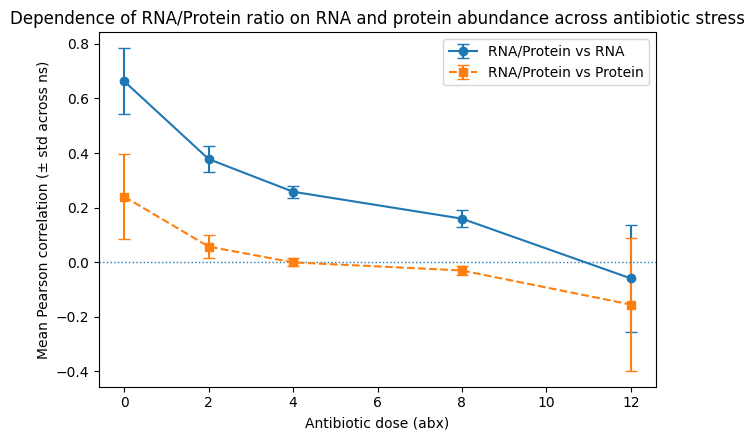

In [22]:
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# DATA (from your tables)
# ============================================================

abx = np.array([0, 2, 4, 8, 12])

# RNA/Protein vs RNA
mean_corr_rna = np.array([0.663046, 0.377691, 0.257956, 0.159267, -0.059778])
std_corr_rna  = np.array([0.120340, 0.048531, 0.022028, 0.030863, 0.195793])

# RNA/Protein vs Protein
mean_corr_prot = np.array([0.239969, 0.056816, -0.000997, -0.030676, -0.155679])
std_corr_prot  = np.array([0.156841, 0.043609, 0.014561, 0.015536, 0.242220])

# ============================================================
# PLOT
# ============================================================

plt.figure(figsize=(6.5, 4.5))

plt.errorbar(
    abx,
    mean_corr_rna,
    yerr=std_corr_rna,
    fmt='o-',
    capsize=4,
    label="RNA/Protein vs RNA"
)

plt.errorbar(
    abx,
    mean_corr_prot,
    yerr=std_corr_prot,
    fmt='s--',
    capsize=4,
    label="RNA/Protein vs Protein"
)

plt.axhline(0, linestyle=':', linewidth=1)

plt.xlabel("Antibiotic dose (abx)")
plt.ylabel("Mean Pearson correlation (± std across ns)")
plt.title("Dependence of RNA/Protein ratio on RNA and protein abundance across antibiotic stress")
plt.legend()
plt.tight_layout()
plt.show()


RAMAN DATA


In [23]:
import numpy as np
import pandas as pd

rna_df     = pd.read_csv("Data/RamanData/rna.csv")
protein_df = pd.read_csv("Data/RamanData/protein.csv")

nutrients = ["caa_gly", "caa_glu", "gly", "glu"]
cm_levels = [0, 2, 4, 8, 12]

records = []

for nutrient in nutrients:
    for cm in cm_levels:
        col = f"Cm{cm}_{nutrient}"

        if col not in rna_df.columns or col not in protein_df.columns:
            continue

        RNA  = rna_df[col].dropna().values
        PROT = protein_df[col].dropna().values

        N = min(len(RNA), len(PROT))
        RNA  = RNA[:N]
        PROT = PROT[:N]

        ratio = RNA / PROT

        for r, p, q in zip(RNA, PROT, ratio):
            records.append({
                "nutrient": nutrient,
                "abx": cm,
                "RNA": r,
                "Protein": p,
                "ratio": q
            })

raman = pd.DataFrame(records)


In [24]:
from scipy.stats import pearsonr, spearmanr

corr_records = []

for (nutrient, abx), g in raman.groupby(["nutrient", "abx"]):

    if len(g) < 10:
        continue  # safety

    rna   = g["RNA"].values
    prot  = g["Protein"].values
    ratio = g["ratio"].values

    corr_records.append({
        "nutrient": nutrient,
        "abx": abx,
        "corr_ratio_rna": pearsonr(rna, ratio)[0],
        "corr_ratio_protein": pearsonr(prot, ratio)[0],
    })

corr_raman = pd.DataFrame(corr_records)


In [26]:
summary_raman = (
    corr_raman
    .groupby("abx")
    .agg(
        mean_corr_rna=("corr_ratio_rna", "mean"),
        std_corr_rna=("corr_ratio_rna", "std"),
        mean_corr_protein=("corr_ratio_protein", "mean"),
        std_corr_protein=("corr_ratio_protein", "std"),
    )
    .reset_index()
)

print(summary_raman)


   abx  mean_corr_rna  std_corr_rna  mean_corr_protein  std_corr_protein
0    0       0.798005      0.095465          -0.033359          0.150105
1    2       0.242869      0.430567          -0.284519          0.244419
2    4      -0.014094      0.460531          -0.324159          0.260220
3    8      -0.022215      0.399693          -0.290202          0.205186
4   12      -0.135316      0.355760          -0.482651          0.084444


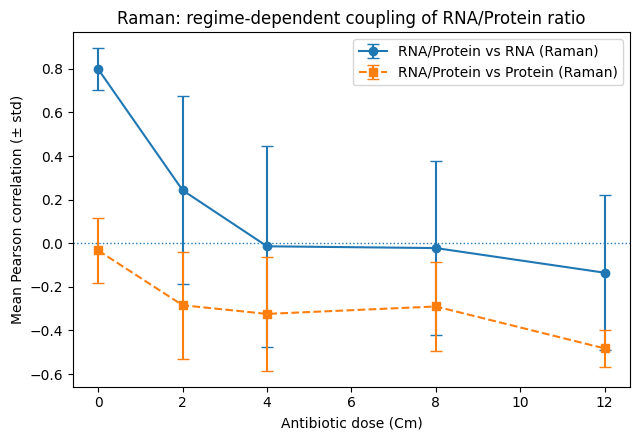

In [27]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6.5, 4.5))

plt.errorbar(
    summary_raman["abx"],
    summary_raman["mean_corr_rna"],
    yerr=summary_raman["std_corr_rna"],
    fmt="o-",
    capsize=4,
    label="RNA/Protein vs RNA (Raman)"
)

plt.errorbar(
    summary_raman["abx"],
    summary_raman["mean_corr_protein"],
    yerr=summary_raman["std_corr_protein"],
    fmt="s--",
    capsize=4,
    label="RNA/Protein vs Protein (Raman)"
)

plt.axhline(0, linestyle=":", linewidth=1)
plt.xlabel("Antibiotic dose (Cm)")
plt.ylabel("Mean Pearson correlation (± std)")
plt.title("Raman: regime-dependent coupling of RNA/Protein ratio")
plt.legend()
plt.tight_layout()
plt.show()


In [28]:
import numpy as np
from scipy.stats import pearsonr, spearmanr

# ============================================================
# Mean correlation vs abx (SIMULATION)
# ============================================================
abx = np.array([0, 2, 4, 8, 12])

sim_corr_rna = np.array([0.663046, 0.377691, 0.257956, 0.159267, -0.059778])
sim_corr_prot = np.array([0.239969, 0.056816, -0.000997, -0.030676, -0.155679])

# ============================================================
# Mean correlation vs abx (RAMAN)
# ============================================================
raman_corr_rna = np.array([0.798005, 0.242869, -0.014094, -0.022215, -0.135316])
raman_corr_prot = np.array([-0.033359, -0.284519, -0.324159, -0.290202, -0.482651])

# ============================================================
# Trend correlation (Pearson + Spearman)
# ============================================================
def compare_trends(x, y, label):
    R, pR = pearsonr(x, y)
    rho, pS = spearmanr(x, y)
    print(f"{label}:")
    print(f"  Pearson  r = {R:.3f}, p = {pR:.3f}")
    print(f"  Spearman ρ = {rho:.3f}, p = {pS:.3f}\n")

compare_trends(sim_corr_rna, raman_corr_rna, "RNA-driven coupling (Simulation vs Raman)")
compare_trends(sim_corr_prot, raman_corr_prot, "Protein-driven coupling (Simulation vs Raman)")

# ============================================================
# Permutation test (trend similarity)
# ============================================================
def permutation_test(x, y, n_perm=10000):
    obs = np.corrcoef(x, y)[0, 1]
    count = 0
    for _ in range(n_perm):
        if abs(np.corrcoef(x, np.random.permutation(y))[0, 1]) >= abs(obs):
            count += 1
    return obs, count / n_perm

obs_rna, p_perm_rna = permutation_test(sim_corr_rna, raman_corr_rna)
obs_prot, p_perm_prot = permutation_test(sim_corr_prot, raman_corr_prot)

print("Permutation test:")
print(f"  RNA coupling    : r = {obs_rna:.3f}, p = {p_perm_rna:.4f}")
print(f"  Protein coupling: r = {obs_prot:.3f}, p = {p_perm_prot:.4f}")


RNA-driven coupling (Simulation vs Raman):
  Pearson  r = 0.942, p = 0.017
  Spearman ρ = 1.000, p = 0.000

Protein-driven coupling (Simulation vs Raman):
  Pearson  r = 0.978, p = 0.004
  Spearman ρ = 0.900, p = 0.037

Permutation test:
  RNA coupling    : r = 0.942, p = 0.0081
  Protein coupling: r = 0.978, p = 0.0269
